Back to [0-Setup.ipynb](0-Setup.ipynb)

# 1. From Task to Flow: Silicon band structure

In DFT, computing the band structure of a material is a two-step procedure:
1. Compute the ground-state density through self-consistent field (SCF) calculation.
2. Compute the electronic eigenvalues along a k-point path through a non-self-consistent field (NSCF) calculation.

With abipy, each Abinit calculation is represented by a `Task` object that runs the calculation inside a working directory,
and several tasks can be gathered into a `Flow`, which takes care of the dependency between the tasks.

This notebook builds the same calculation twice: First, as two individual tasks. Then, as a flow.


**Useful links:**
* [Index of Abinit input variables](https://docs.abinit.org/variables/#A)


## In the shell

The content of this notebook is reproduced in the following scripts from the `Examples/` folder:

* `run_si_gstate.py`
* `run_si_nscf.py`
* `plot_si_nscf.py`
* `run_si_ebands.py`
* `make_si_ebands.py`
* `plot_si_ebands.py`

See the file `Examples/README.md` for instructions to run them.

## Notebook initialization

In [1]:
from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

from abipy import abilab
import abipy.flowtk as flowtk
abilab.enable_notebook()

%matplotlib inline

import workshop_lib as wlib

## 1.1 Ground-state density as a single Task

We will use the following functions to construct the task for a ground-state calculation in silicon.

In [5]:
wlib.print_source(wlib.si_gs_input)
wlib.print_source(wlib.build_si_gs_task)

A few important input variables are worth mentioning:
* [`ecut`](https://docs.abinit.org/variables/basic/#ecut) : The kinetic energy cutoff, in Hartree.
* [`ngkpt`](https://docs.abinit.org/variables/basic/#ngkpt) : The k-points grid to sample the wavevectors in reciprocal space.
* [`tolvrs`](https://docs.abinit.org/variables/basic/#tolvrs) : The convergence criterion on the potential in the self-consistent field calculation.

Now, let's initialize the task object.

In [ ]:
# Create the task
task = wlib.build_si_gs_task(workdir="task_si_gstate")

# Set the number of processors for this task, and set a time limit.
task = wlib.setup_task_manager(task, mpi_procs=4, timelimit_hour=0.1)

If you want, you can print out the definition of `setup_task_manager` alongside the others.

Let's proceed to build the task.

In [6]:
# Remove a previous run, if it exists.
if Path(task.workdir).exists():
    task.rmtree()

# Build the task
task.build()
task.make_links()

The following directory structure that has been created.

    task_si_gstate/
    ├── abipy_meta.json
    ├── job.sh             <-- script to execute (submit) the task
    ├── run.abi            <-- abinit input file
    ├── indata/
    ├── outdata/         
    └── tmpdata/

As you may guess, the other directories are for input data, output data, and temporary data.

Have a look at the main input file `run.abi`. You will see that several input variables have been set automatically by abipy.
You can look them up in the [index of Abinit input variables](https://docs.abinit.org/variables/#A).

Now, let's run the task:

In [ ]:
# Run the task
task.start_and_wait()

In [ ]:
# Print out the status of the task
task.check_status()

Once the calculation completes, the task directory contains the following files.

    task_si_gstate/
    ├── __startlock__
    ├── abipy_meta.json
    ├── job.sh
    ├── run.abi
    ├── run.abo                <-- abinit output file
    ├── run.err
    ├── run.log                <-- abinit log has extra info
    ├── indata/
    ├── outdata/
    │   ├── out_DDB.nc
    │   ├── out_DEN.nc         <-- Density file
    │   ├── out_EBANDS.agr
    │   ├── out_EIG
    │   ├── out_EIG.nc
    │   ├── out_GSR.nc         <-- Ground state results.
    │   ├── out_OUT.nc         <-- Input variables and outputs.
    │   └── out_WFK.nc         <-- Large wavefunctions file (remove if you don't need it).
    └── tmpdata/


The ground state results file `out_GSR.nc` has most of the results we care about. We can read out the total energy like this:

In [8]:
with abilab.abiopen("task_si_gstate/outdata/out_GSR.nc") as gsr:
    print("energy:", gsr.energy)

energy: -229.77702155260482 eV


## 1.2 Band structure calculation in a second, dependent Task

Now, we compute the band structure task by generating the input for a non-self-consistent-field (NSCF) calculation,
which needs the density file produced in Step 1.


In [16]:
wlib.print_source(wlib.si_bandstructure_input)
wlib.print_source(wlib.build_si_nscf_task)

A few important input variables are worth mentioning:
* [`nband`](https://docs.abinit.org/variables/basic/#nband) : The number of bands to be computed. In step 1, we only needed the occupied bands, but now we want to compute a few more empty bands to show in the band structure.
* [`kptbounds`](https://docs.abinit.org/variables/gstate/#kptbounds) : The high-symmetry k-points which define the k-points path for the band structure.
* [`ndivsm`](https://docs.abinit.org/variables/gstate/#ndivsm) : The number of divisions for the segments between the high-symmetry k-points. This defines the total number of k-points that will be computed.
* [`tolwfr`](https://docs.abinit.org/variables/basic/#tolwfr) : The convergence criterion on the wavefunctions. In a NSCF calculation, the potential is already computed, and we only need to diagonalize the hamiltonian once to get the wavefunctions and the eigenvalues.

Notice the dependency: `deps = {density: 'DEN'}`, where `density` is just
the **string path** to Step 1's density file.
We assume that this file will exist when the task starts.

In [7]:
# Create the task
task = wlib.build_si_nscf_task(workdir="task_si_nscf", density="task_si_gstate/outdata/out_DEN.nc")

# Set the number of processors for this task, and set a time limit.
task = wlib.setup_task_manager(task, mpi_procs=4, timelimit_hour=0.1)

Now run the task

In [ ]:
# Remove a previous run, if it exists.
if Path(task.workdir).exists():
    task.rmtree()

# Build the task
task.build()
task.make_links()

In [ ]:
# Run the task
task.start_and_wait()

In [ ]:
# Print out the status of the task
task.check_status()

Finally, we extract the band structure from the output `GSR.nc` file and plot it.

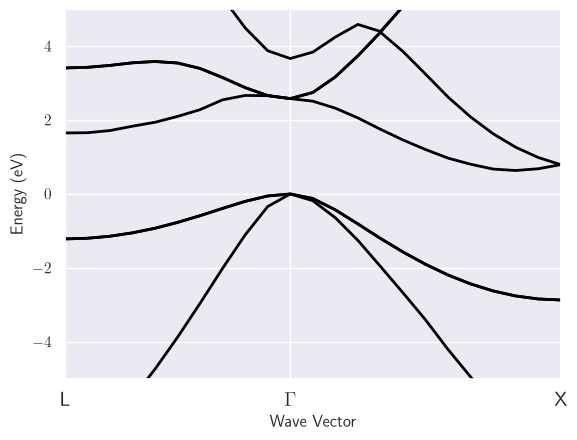

In [9]:
with abilab.abiopen("task_si_nscf/outdata/out_GSR.nc") as gsr:
    ebands = gsr.ebands

fig = ebands.plot(color="k", ylims=(-5,5), show=True)

## 1.3 Wrapping both Tasks in a Flow

Since the NSCF task depends on the SCF task, it makes sense to gather them in a `Flow`.

We use the following functions:

In [13]:
wlib.print_source(wlib.build_si_ebands_task_flow)
wlib.print_source(wlib.setup_manager)

Notice how the dependency between the tasks is taken care of.
The `gs_task` object is passed in lieu of the density file.

In [3]:
# Create the flow
flow = wlib.build_si_ebands_task_flow(workdir='flow_si_ebands')

# Set number of processors
flow = wlib.setup_manager(flow, mpi_procs=4)

### Build it, write it, run it


In [4]:
# Remove a previous run, if it exists.
if Path(flow.workdir).exists():
    flow.rmtree()

In [ ]:
# Write the flow
flow.build_and_pickle_dump()

At this point, the following directory structure has been created:

    flow_si_ebands/
    ├── __AbinitFlow__.pickle
    ├── _fix_flow.py
    ├── make_si_ebands.py
    ├── indata/
    ├── outdata/                     <-- Gather output data from the works in this directory
    ├── tmpdata/
    └── w0/                          <-- Work 0
        ├── t0/                      <---- Task 0 of Work 0: Ground state calculation
        │   ├── abipy_meta.json
        │   ├── indata/
        │   ├── job.sh
        │   ├── outdata/
        │   ├── run.abi
        │   └── tmpdata/
        ├── t1/                      <---- Task 1 of Work 0: NSCF calculation for the band structure.
        │   ├── abipy_meta.json
        │   ├── indata/
        │   ├── job.sh
        │   ├── outdata/
        │   ├── run.abi
        │   └── tmpdata/
        ├── indata/
        ├── outdata/                 <---- Gather output data from the tasks in this directory
        └── tmpdata

In [ ]:
# Run each of the works and tasks sequentially and wait for the result.
for work in flow:
    for task in work:
        task.start_and_wait()

        # Report calculation status
        print(f'Status of task {task.name}: {task.check_status()}')

If you see that both tasks are Completed, you can plot the band structure right away.
But consider the following approach, where we don't run the flow right away:

### Build it now, run it later

Let's build the flow again.

In [ ]:
# Create the flow
flow = wlib.build_si_ebands_task_flow(workdir='flow_si_ebands')
flow = wlib.setup_manager(flow, mpi_procs=4)

# Remove a previous run, if it exists.
if Path(flow.workdir).exists():
    flow.rmtree()

# Write the flow
flow.build_and_pickle_dump()

This time, we run the flow in the shell using the `abirun.py` executable:

    abirun.py flow_si_ebands scheduler

In this notebook, we use our wrapper function to execute the shell command above:

In [5]:
wlib.shell_command("abirun.py flow_si_ebands scheduler", silent=True)

While the flow is running in the background, you can check its progression like so:

In [ ]:
# Run this cell several times to see progress
wlib.shell_command('abirun.py flow_si_ebands status')

And so, this is the preferred way to run Abinit calculations with abipy:
1. Use a python script to build a flow.
2. Run the flow with the `abirun.py` executable.

There are several advantages to this approach, compared to a script that builds and runs the flow right away.
It allows to interact with the job submission system on a supercomputing clusters, and it allows to handle arbitrary task dependencies.



### Plot the band structure

Finally, let us look at a function that extract the band structure from a flow directory and plots it.


In [23]:
wlib.print_source(wlib.plot_ebands)

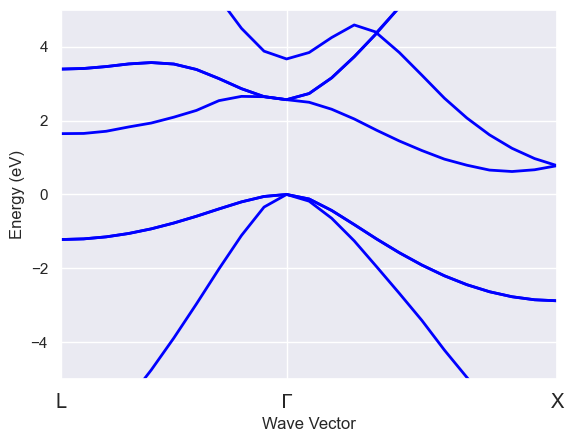

In [7]:
# Plot the band structure and display the resulting figure
fig = wlib.plot_ebands('flow_si_ebands', figname='', ylims=(-5,5), show=True)

## About flows

### Can I modify my flow after building it?

Yes, but you shouldn't.
If you change the calculation parameters, it is advised you remove the flow_ directory and build it anew.
This is also true if you need to *move* the flow directoty: you should instead move the make_ script and rerun it in the new directory.

### My flow has crashed. Can I restart it?

Yes. Just resubmit the individual tasks' `job.sh` scripts to run them and pick up where you left.
The `abirun.py` script also allows you to set by hand the status of the tasks.


# Next
Continue with [`2-Convergence_study.ipynb`](2-Convergence_study.ipynb).